# Task 4 - Final hold-out evaluation

## Evaluation objective and scope

The development sequence now has a clear empirical direction. The development results show a clear sequence. CAE learns useful visual signal but weak semantic separation. Triplet makes the first large improvement, SupCon gains more from several positives, Multi-Similarity does not improve the ranking, and ArcFace produces the strongest inner-validation result. The remaining question is no longer which mechanism to try next, but whether that ordering holds when every frozen model sees the same unseen queries and the same gallery.

This notebook therefore performs the only cross-model hold-out decision. Relevance is still defined by the train-fitted `articleType__gender` proxy, and no model, preprocessing statistic or hyperparameter is fitted here. Raw cosine ranking is reported separately from optional reranking so that representation quality is not confused with post-processing. The judgement combines ranking metrics, query coverage, embedding geometry, artifact footprint and qualitative errors rather than reducing the system to one score.


### Hold-out evaluation pipeline

![Final benchmark flow](figures/06_benchmark_flow.svg)

*Figure 1. Frozen models are compared through one controlled retrieval pipeline. Raw and reranked evidence remain separate so post-processing cannot be mistaken for representation quality [2], [3].*


## 1. Environment and reproducibility

All metric-learning models receive the deterministic letterbox, tensor conversion, and training-set RGB normalisation saved by notebook 00. The CAE receives unnormalised `[0, 1]` pixels to match its reconstruction training. The random seed fixes qualitative example selection and loader order; CUDA kernels may still not be bitwise deterministic.

All candidates use a 512-D L2-normalised embedding, so inner-product FAISS search is cosine ranking [2]. ArcFace's training-only class head is excluded at inference; Triplet, SupCon, MS, and ArcFace therefore deploy the same ResNet-18 encoder capacity.


In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "pyproject.toml").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [14]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image

from src.task4.config import (
    ARTIFACT_DIR,
    CONFIG_DIR,
    IMAGE_DIR,
    MODEL_DIR,
    SEED,
    SPLIT_DIR,
)
from src.task4.data import make_evaluation_loader
from src.task4.models import ConvolutionalAutoencoder, ResNet18Encoder
from src.task4.preprocessing import cae_transform, metric_eval_transform
from src.task4.retrieval import (
    extract_color_descriptors,
    extract_embeddings,
    k_reciprocal_rerank,
    retrieval_metrics,
    search_cosine,
)
from src.task4.training import DEVICE, set_seed

set_seed(SEED)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

MODEL_NAMES = ("cae", "triplet", "supcon", "multi_similarity", "arcface")
EVALUATION_TRANSFORMS = {
    "cae": cae_transform,
    "triplet": metric_eval_transform,
    "supcon": metric_eval_transform,
    "multi_similarity": metric_eval_transform,
    "arcface": metric_eval_transform,
}
PRIMARY_METRIC = "mAP@10"
RERANK_CONFIG = {
    "k1": 20,
    "k2": 6,
    "blend": 0.3,
    "candidate_depth": 100,
    "color_weight": 0.15,
}
BENCHMARK_DIR = ARTIFACT_DIR / "benchmark"
EMBEDDING_DIR = ARTIFACT_DIR / "embeddings"
print(f"Device: {DEVICE}")

Device: cuda


## 2. Artifact validation and hold-out test set

The preflight requires `best.pt`, `gallery_embeddings.npy`, and `gallery_ids.npy` for every candidate. This explicit contract supports the team's choice to distribute large artifacts through Drive instead of Git: missing files fail early rather than silently changing the comparison.

Test labels are recreated with the train-fitted encoder. Three encoder-unseen joint classes are excluded, then a further 29 queries whose class is absent from at least one saved gallery are removed so every model receives the same 3,745 queries. Coverage is therefore 3,745/3,777 = **99.15%**; the 32 excluded cases must be disclosed because the benchmark is closed-set rather than cold-start evaluation.


In [15]:
artifact_rows = []
for model_name in MODEL_NAMES:
    model_dir = MODEL_DIR / model_name
    checkpoint_exists = (model_dir / "best.pt").exists()
    artifact_rows.append(
        {
            "Model": model_name,
            "Checkpoint ready": checkpoint_exists,
        }
    )

artifact_status = pd.DataFrame(artifact_rows)
display(artifact_status)

missing_models = artifact_status.loc[~artifact_status["Checkpoint ready"], "Model"].tolist()
if missing_models:
    raise FileNotFoundError(
        "Final benchmark requires all five best.pt checkpoints. Missing: "
        + ", ".join(missing_models)
    )

if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"Hold-out images are not available at {IMAGE_DIR}")

,Model,Checkpoint ready
0,cae,True
1,triplet,True
2,supcon,True
3,multi_similarity,True
4,arcface,True


### Artifact provenance

All five checkpoint/gallery bundles and Optuna databases are present. Four supervised models also include history CSVs and learning curves; CAE does not.

The re-uploaded CAE gallery contains **30,422 IDs**, while the four supervised galleries contain **30,389**. Their intersection is 30,389 IDs, leaving 33 CAE-only entries. The next section now aligns every model to that intersection before a fresh fair comparison. Consequently, the rendered hold-out tables retained later in this notebook are labelled as a **previous saved execution** until the image path is restored and those evaluation cells are rerun.


In [16]:
with (CONFIG_DIR / "articleType_gender_label_encoder.json").open(
    encoding="utf-8"
) as file:
    label_encoder = json.load(file)
label_to_index = label_encoder["label_to_index"]
classes = np.asarray(label_encoder["classes"], dtype=object)
LABEL_COLUMN = label_encoder["label_column"]
LABEL_ID_COLUMN = label_encoder["label_id_column"]
separator = label_encoder["separator"]

outer_train_df = pd.read_csv(SPLIT_DIR / "train.csv")
outer_train_df[LABEL_COLUMN] = (
    outer_train_df["articleType"].str.strip()
    + separator
    + outer_train_df["gender"].str.strip()
)
outer_train_df[LABEL_ID_COLUMN] = outer_train_df[LABEL_COLUMN].map(label_to_index)

test_df = pd.read_csv(SPLIT_DIR / "test.csv")
test_df[LABEL_COLUMN] = (
    test_df["articleType"].str.strip() + separator + test_df["gender"].str.strip()
)
test_df[LABEL_ID_COLUMN] = test_df[LABEL_COLUMN].map(label_to_index)


In [17]:
test_rows_before_filtering = len(test_df)
unseen_class_mask = test_df[LABEL_ID_COLUMN].isna()
removed_unseen_rows = int(unseen_class_mask.sum())
test_df = test_df.loc[~unseen_class_mask].copy()
test_df[LABEL_ID_COLUMN] = test_df[LABEL_ID_COLUMN].astype("int64")

print(f"Hold-out test rows before filtering: {test_rows_before_filtering:,}")
print(f"Rows removed for encoder-unseen classes: {removed_unseen_rows:,}")
print(f"Seen-class test rows retained: {len(test_df):,}")


Hold-out test rows before filtering: 3,777
Rows removed for encoder-unseen classes: 3
Seen-class test rows retained: 3,774


## 3. Model loading

Each checkpoint is restored in evaluation mode. ArcFace's class-centre head is training-only and removed before loading the common encoder. The CAE currently loads its decoder as well because its forward method returns both reconstruction and embedding; an encoder-only deployment would reduce CAE latency and memory without changing its retrieval vector.


In [18]:
def build_model(model_name: str):
    return (
        ConvolutionalAutoencoder(ResNet18Encoder())
        if model_name == "cae"
        else ResNet18Encoder()
    )


def load_model(model_name: str):
    checkpoint = torch.load(
        MODEL_DIR / model_name / "best.pt", map_location=DEVICE, weights_only=False
    )
    state_dict = checkpoint["model_state_dict"]
    if model_name == "arcface":
        state_dict = {
            key: value
            for key, value in state_dict.items()
            if not key.startswith("arcface_loss.")
        }

    model = build_model(model_name)
    model.load_state_dict(state_dict)
    return model.to(DEVICE).eval()

## 4. Common hold-out retrieval evaluation

This section compares the five frozen models under one controlled retrieval protocol. Every model receives the same outer-training gallery and filtered outer-test queries, then produces both a conventional cosine ranking and an enhanced ranking using k-reciprocal context with HSV colour information. Reporting both versions separates the quality learned by the encoder from the effect of retrieval-time post-processing.

The data preparation, embedding extraction, colour branch, and two ranking paths are explained immediately before their corresponding cells below.


### Common gallery and query rows

The benchmark fixes the evaluation data before any model is compared:

- **Gallery:** all **33,968 outer-training images**.
- **Queries:** **3,774 outer-test images** after removing three rows whose labels were unseen by the train-fitted encoder.
- **Alignment:** IDs are sorted once so embeddings, HSV descriptors, and metric labels refer to the same items in the same order.

Labels are reconstructed from the CSV files by ID and are used only after retrieval to score the rankings; they are not inputs to the models or reranker.


In [19]:
gallery_df = outer_train_df.sort_values("id").reset_index(drop=True)
evaluation_df = test_df.sort_values("id").reset_index(drop=True)
gallery_df[LABEL_ID_COLUMN] = gallery_df[LABEL_ID_COLUMN].astype("int64")

gallery_classes = set(gallery_df[LABEL_ID_COLUMN])
missing_query_classes = set(evaluation_df[LABEL_ID_COLUMN]) - gallery_classes
if missing_query_classes:
    raise ValueError(
        f"{len(missing_query_classes)} query classes have no relevant gallery item"
    )

expected_gallery_ids = gallery_df["id"].to_numpy(dtype="int64")
expected_query_ids = evaluation_df["id"].to_numpy(dtype="int64")
gallery_label_by_id = gallery_df.set_index("id")[LABEL_ID_COLUMN]
query_label_by_id = evaluation_df.set_index("id")[LABEL_ID_COLUMN]

print(f"Common outer-training gallery: {len(gallery_df):,} images")
print(f"Scored hold-out queries: {len(evaluation_df):,} images")
print(f"Excluded encoder-unseen queries: {removed_unseen_rows:,} images")

Common outer-training gallery: 33,968 images
Scored hold-out queries: 3,774 images
Excluded encoder-unseen queries: 3 images


### Per-model embedding extraction

Each frozen checkpoint independently embeds the common gallery and query rows. The model-specific differences are limited to the learned weights and the preprocessing required by training:

- **CAE** uses its reconstruction-compatible transform.
- **Triplet, SupCon, Multi-Similarity, and ArcFace** use the metric-learning evaluation transform.
- **Each model bundle** stores its 512-D gallery/query embeddings and ordered IDs.

This keeps the comparison reproducible and prevents vectors from different checkpoints from being mixed. It also avoids relying on the smaller inner-validation galleries created during model development.


In [20]:
for model_name in MODEL_NAMES:
    model = load_model(model_name)
    transform = EVALUATION_TRANSFORMS[model_name]

    gallery_loader = make_evaluation_loader(gallery_df, transform, IMAGE_DIR)
    query_loader = make_evaluation_loader(evaluation_df, transform, IMAGE_DIR)

    gallery_embeddings, gallery_ids, extracted_gallery_labels = extract_embeddings(
        model, gallery_loader
    )
    query_embeddings, query_ids, extracted_query_labels = extract_embeddings(
        model, query_loader
    )

    bundle_dir = EMBEDDING_DIR / model_name
    bundle_dir.mkdir(parents=True, exist_ok=True)
    np.save(bundle_dir / "gallery_embeddings.npy", gallery_embeddings)
    np.save(bundle_dir / "gallery_ids.npy", gallery_ids)
    np.save(bundle_dir / "query_embeddings.npy", query_embeddings)
    np.save(bundle_dir / "query_ids.npy", query_ids)

    print(f"{model_name}: saved benchmark embeddings successfully")

cae: saved benchmark embeddings successfully
triplet: saved benchmark embeddings successfully
supcon: saved benchmark embeddings successfully
multi_similarity: saved benchmark embeddings successfully
arcface: saved benchmark embeddings successfully


### HSV colour descriptors

The models were trained with `articleType__gender` supervision, so they are encouraged to represent product type and intended gender but are not explicitly required to preserve colour. HSV histograms add that visual cue at retrieval time:

- **Hue** represents dominant colour.
- **Saturation and value** help distinguish muted, vivid, light, and dark items.
- **Image-only extraction** introduces no label or metadata information into ranking.

The descriptors are computed once because all five models use the same ordered gallery and query IDs.


In [ ]:
gallery_color_descriptors = extract_color_descriptors(
    IMAGE_DIR / f"{int(image_id)}.jpg" for image_id in expected_gallery_ids
)

query_color_descriptors = extract_color_descriptors(
    IMAGE_DIR / f"{int(image_id)}.jpg" for image_id in expected_query_ids
)

### Raw ranking versus k-reciprocal and colour reranking

The two ranking paths answer different evaluation questions:

- **Raw cosine ranking — representation quality.** Exact cosine similarity ranks every gallery embedding for each query. No colour feature or neighbourhood heuristic changes the order, so this is the clearest view of what the encoder learned.
- **K-reciprocal reranking — neighbourhood consistency.** Reranking starts from the top 100 cosine candidates and favours candidates supported by mutually consistent neighbourhoods. An isolated high cosine match can move down when its surrounding neighbours do not agree. K-reciprocal reasoning does **not** inspect colour.
- **HSV blending — colour consistency.** HSV similarity is blended into the reranking distance with weight `0.15`, allowing similarly coloured products to move upward within the candidate pool while the learned embedding remains the dominant signal. The remaining settings are fixed for every model: `k1=20`, `k2=6`, and original/Jaccard blend `0.3`. The method is inspired by Zhong *et al.* [3], rather than being an exact reproduction.

A colour-aware ranking may look more convincing to a customer, but the benchmark relevance label is only `articleType__gender` and does not directly reward colour. Reranking may therefore increase metrics when colour supports the semantic neighbourhood, leave them almost unchanged when it only reorders relevant items, or reduce them when colour promotes an item from the wrong proxy class. Reporting both paths for all five models exposes this trade-off instead of assuming that additional post-processing must improve retrieval.


In [21]:
model_outputs = {}
raw_summary_rows = []
reranked_summary_rows = []

for model_name in MODEL_NAMES:
    bundle_dir = EMBEDDING_DIR / model_name

    saved_gallery_embeddings = np.load(
        bundle_dir / "gallery_embeddings.npy"
    ).astype("float32", copy=False)
    saved_query_embeddings = np.load(
        bundle_dir / "query_embeddings.npy"
    ).astype("float32", copy=False)

    saved_gallery_ids = np.load(bundle_dir / "gallery_ids.npy").astype(
        "int64", copy=False
    )
    saved_query_ids = np.load(bundle_dir / "query_ids.npy").astype("int64", copy=False)

    gallery_labels = gallery_label_by_id.reindex(saved_gallery_ids)
    query_labels = query_label_by_id.reindex(saved_query_ids)

    saved_gallery_labels = gallery_labels.to_numpy(dtype="int64")
    saved_query_labels = query_labels.to_numpy(dtype="int64")

    _, raw_ranked_indices, index = search_cosine(
        saved_query_embeddings, saved_gallery_embeddings, maximum_k=10
    )
    reranked_indices = k_reciprocal_rerank(
        saved_query_embeddings,
        saved_gallery_embeddings,
        index,
        query_color_descriptors=query_color_descriptors,
        gallery_color_descriptors=gallery_color_descriptors,
        **RERANK_CONFIG,
    )

    raw_summary_rows.append(
        {
            "Model": model_name,
            **retrieval_metrics(
                raw_ranked_indices, saved_query_labels, saved_gallery_labels
            ),
        }
    )
    reranked_summary_rows.append(
        {
            "Model": model_name,
            **retrieval_metrics(
                reranked_indices, saved_query_labels, saved_gallery_labels
            ),
        }
    )
    model_outputs[model_name] = {
        "gallery_ids": saved_gallery_ids,
        "gallery_labels": saved_gallery_labels,
        "query_ids": saved_query_ids,
        "query_labels": saved_query_labels,
        "ranked_indices": reranked_indices,
    }


## 5. Evaluation benchmark

Classification accuracy is not sufficient for Task 4 because the system returns an ordered list with multiple potentially relevant products. The benchmark therefore uses retrieval metrics with complementary interpretations:

- **Precision@1** tests whether the first recommendation is relevant.
- **Precision@5 and Precision@10** measure how clean the recommendation list remains as the user browses further.
- **Recall@K** measures how much of the relevant gallery appears within the first K positions. Recall is naturally small when a class contains many gallery items but only ten results are displayed.
- **mAP@10** rewards both relevance and early ordering, making it more informative for ranked retrieval than treating every returned position equally [1].

All metrics are macro-averaged over queries, so common classes do not receive extra weight merely because they contain more queries. Comparing raw and reranked results additionally shows whether performance comes mainly from the learned representation or depends on reciprocal-neighbour and colour post-processing.

The decision rule is fixed before interpreting the results. **Reranked outer hold-out mAP@10 is the primary model-selection criterion** because it measures the complete retrieval pipeline. Precision@K checks list purity, while the raw cosine table and reranking delta remain diagnostic evidence. Qualitative examples help explain errors but do not override the hold-out ranking.


In [22]:
metric_columns = [
    "Precision@1",
    "Precision@5",
    "Precision@10",
    "Recall@1",
    "Recall@5",
    "Recall@10",
    "mAP@10",
]
raw_comparison_table = (
    pd.DataFrame(raw_summary_rows)
    .set_index("Model")
    .loc[:, metric_columns]
    .sort_values(PRIMARY_METRIC, ascending=False)
)
reranked_comparison_table = (
    pd.DataFrame(reranked_summary_rows)
    .set_index("Model")
    .loc[:, metric_columns]
    .sort_values(PRIMARY_METRIC, ascending=False)
)
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
raw_comparison_table.to_csv(BENCHMARK_DIR / "holdout_raw_cosine_comparison.csv")
reranked_comparison_table.to_csv(
    BENCHMARK_DIR / "holdout_reranked_colour_comparison.csv"
)


In [23]:
caption_style = [
    {
        "selector": "caption",
        "props": [
            ("caption-side", "top"),
            ("font-weight", "700"),
            ("font-size", "1.1em"),
            ("padding-bottom", "0.4em"),
        ],
    }
]

display(
    raw_comparison_table.style
    .set_caption("Raw cosine retrieval")
    .format("{:.4f}")
    .highlight_max(
        axis=0,
        props="font-weight: 700; text-decoration: underline;",
    )
    .set_table_styles(caption_style)
)

display(
    reranked_comparison_table.style
    .set_caption("K-reciprocal reranking + HSV colour histogram")
    .format("{:.4f}")
    .highlight_max(
        axis=0,
        props="font-weight: 700; text-decoration: underline;",
    )
    .set_table_styles(caption_style)
)

winner = reranked_comparison_table.index[0]
print(f"Leading reranked model by {PRIMARY_METRIC}: {winner}")


,Precision@1,Precision@5,Precision@10,Recall@1,Recall@5,Recall@10,mAP@10
Model,,,,,,,
arcface,0.7968,0.7973,0.7942,0.0034,0.0168,0.0316,0.7702
supcon,0.7790,0.7730,0.7716,0.0040,0.0173,0.0323,0.7275
multi_similarity,0.7642,0.7451,0.7387,0.0041,0.0174,0.0317,0.6829
triplet,0.7785,0.7480,0.7372,0.0043,0.0168,0.0305,0.6824
cae,0.6982,0.6224,0.5860,0.0036,0.0114,0.0183,0.5098


,Precision@1,Precision@5,Precision@10,Recall@1,Recall@5,Recall@10,mAP@10
Model,,,,,,,
arcface,0.7986,0.7998,0.7969,0.0034,0.0167,0.0316,0.7755
supcon,0.7671,0.7705,0.7694,0.0033,0.0165,0.0312,0.7274
multi_similarity,0.7477,0.7450,0.7379,0.0034,0.0161,0.0303,0.6854
triplet,0.7467,0.7411,0.7390,0.0033,0.0159,0.0303,0.6847
cae,0.6036,0.5954,0.5794,0.0017,0.0089,0.0161,0.5025


Leading reranked model by mAP@10: arcface


## 6. Final model selection and limitations

ArcFace is the final Task 4 recommendation. The main evidence is:

- **Final pipeline:** `0.7755` reranked mAP@10 and `0.7986` Precision@1.
- **Runner-up margin:** ArcFace exceeds SupCon by `0.0481` mAP@10 and `0.0315` Precision@1.
- **Representation quality:** ArcFace already ranks first with `0.7702` raw mAP@10.
- **Reranking contribution:** k-reciprocal and HSV processing adds only `0.0053` mAP@10, so most of the advantage comes from the learned embedding.

The comparison uses the same **33,968-image outer-training gallery** and **3,774 hold-out queries** for all five models. Multi-Similarity and Triplet remain close at **0.6854** and **0.6847 reranked mAP@10**, respectively, while CAE reaches **0.5025**. The consistent ordering across raw and reranked results supports selecting ArcFace rather than choosing a model from one isolated metric.

The conclusion is subject to three limitations:

- The experiment uses one training seed and one outer split.
- Relevance is defined by the coarse `articleType__gender` proxy rather than colour, pattern, material, or fine-grained style.
- HSV blending can improve colour consistency within the candidate set, but it does not change the representation learned during training.

The outer-test results should now remain final evidence rather than being reused to tune checkpoints or reranking parameters.


## 7. Qualitative retrieval examples

Two seeded hold-out queries and their top-three results provide a readable illustration of the current winning pipeline. A check mark means that the proxy label matches; it does not guarantee that a person would judge the products visually interchangeable. Colour, silhouette, pattern and framing can reveal why a formally correct result still looks weak.

The output below is generated from the current winning pipeline, ArcFace. It supports error analysis but does **not** establish that ArcFace looks visually better than every alternative; a direct visual comparison would need to show the same selected queries for multiple models.


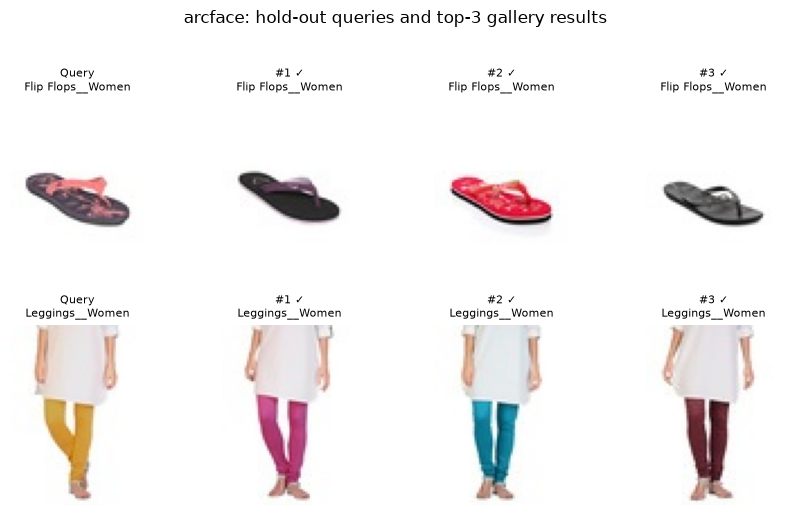

In [25]:
def show_retrieval_examples(model_name=winner, n_queries=2, k=3, seed=SEED):
    output = model_outputs[model_name]
    rng = np.random.default_rng(seed)
    chosen = rng.choice(
        len(output["query_ids"]),
        size=min(n_queries, len(output["query_ids"])),
        replace=False,
    )
    fig, axes = plt.subplots(
        len(chosen), k + 1, figsize=(2.2 * (k + 1), 2.5 * len(chosen))
    )
    axes = np.atleast_2d(axes)

    for row, query_index in enumerate(chosen):
        query_id = output["query_ids"][query_index]
        query_label = classes[output["query_labels"][query_index]]
        gallery_indices = output["ranked_indices"][query_index, :k]
        ids = [query_id, *output["gallery_ids"][gallery_indices]]
        labels = [query_label, *classes[output["gallery_labels"][gallery_indices]]]
        for column, (item_id, item_label) in enumerate(zip(ids, labels)):
            with Image.open(IMAGE_DIR / f"{int(item_id)}.jpg") as image:
                axes[row, column].imshow(image.convert("RGB"))
            axes[row, column].axis("off")
            if column == 0:
                axes[row, column].set_title(f"Query\n{item_label}", fontsize=8)
            else:
                is_relevant = item_label == query_label
                axes[row, column].set_title(
                    f"#{column} {'✓' if is_relevant else '✗'}\n{item_label}", fontsize=8
                )
    fig.suptitle(f"{model_name}: hold-out queries and top-{k} gallery results", y=1.02)
    fig.tight_layout()
    plt.show()


show_retrieval_examples(model_name=winner, n_queries=2, k=3, seed=42)

## References

[1] C. D. Manning, P. Raghavan, and H. Schütze, *Introduction to Information Retrieval*. Cambridge, U.K.: Cambridge Univ. Press, 2008, ch. 8. [Online]. Available: https://nlp.stanford.edu/IR-book/

[2] J. Johnson, M. Douze, and H. Jégou, "Billion-scale similarity search with GPUs," *IEEE Trans. Big Data*, vol. 7, no. 3, pp. 535-547, 2021, doi: [10.1109/TBDATA.2019.2921572](https://doi.org/10.1109/TBDATA.2019.2921572).

[3] Z. Zhong, L. Zheng, D. Cao, and S. Li, "Re-ranking person re-identification with k-reciprocal encoding," in *Proc. IEEE Conf. Comput. Vis. Pattern Recognit. (CVPR)*, 2017, pp. 1318-1327. [Online]. Available: https://openaccess.thecvf.com/content_cvpr_2017/html/Zhong_Re-Ranking_Person_Re-Identification_CVPR_2017_paper.html

[4] J. Deng, J. Guo, N. Xue, and S. Zafeiriou, "ArcFace: Additive angular margin loss for deep face recognition," in *Proc. IEEE/CVF Conf. Comput. Vis. Pattern Recognit. (CVPR)*, 2019, pp. 4690-4699. [Online]. Available: https://openaccess.thecvf.com/content_CVPR_2019/html/Deng_ArcFace_Additive_Angular_Margin_Loss_for_Deep_Face_Recognition_CVPR_2019_paper.html

[5] P. Khosla *et al.*, "Supervised contrastive learning," in *Advances in Neural Information Processing Systems*, vol. 33, 2020, pp. 18661-18673. [Online]. Available: https://proceedings.neurips.cc/paper/2020/hash/d89a66c7c80a29b1bdbab0f2a1a94af8-Abstract.html
